In [39]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

carga del dataset

In [40]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  
    transforms.Resize((48, 48)),                 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dir = "./train"
test_dir = "./test"

trainset = datasets.ImageFolder(root=train_dir, transform=transform)
testset = datasets.ImageFolder(root=test_dir, transform=transform)

classes = trainset.classes
print("Clases:", classes)
print("Cantidad en train:", len(trainset))
print("Cantidad en test:", len(testset))




Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Cantidad en train: 28709
Cantidad en test: 7178


dataloader


In [41]:
dataloader = {
    'train': DataLoader(trainset, batch_size=32, shuffle=True),
    'val': DataLoader(testset, batch_size=1000, shuffle=False)
}

In [42]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(D_in=48*48, H1=2000, H2=1000, H3=500, D_out=7, p=0.5):
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(D_in, H1),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H1, H2),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H2, H3),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H3, D_out)
    )




funcion de entrenamiento

In [43]:
def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # evaluación en validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(y_pred, axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')  # solo pesos
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} | loss {l[-1]:.5f} acc {acc[-1]:.5f} | val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # cargar mejor modelo de forma segura
    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


sgd


In [44]:

model = build_model(D_in=48*48, H1=2000, H2=1000, H3=500, D_out=len(classes),p=0.5)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
hist_sgd = fit(model, dataloader, optimizer)


Mejor modelo guardado con acc 0.25707 en epoch 1
Mejor modelo guardado con acc 0.31018 en epoch 2
Mejor modelo guardado con acc 0.37839 en epoch 3
Mejor modelo guardado con acc 0.38996 en epoch 4
Mejor modelo guardado con acc 0.40152 en epoch 5
Mejor modelo guardado con acc 0.40197 en epoch 6
Mejor modelo guardado con acc 0.40582 en epoch 7
Mejor modelo guardado con acc 0.42204 en epoch 8
Epoch 10/100 | loss 1.53885 acc 0.40325 | val_loss 1.55076 val_acc 0.41205
Mejor modelo guardado con acc 0.42949 en epoch 11
Mejor modelo guardado con acc 0.43083 en epoch 15
Mejor modelo guardado con acc 0.43776 en epoch 16
Mejor modelo guardado con acc 0.44295 en epoch 17
Mejor modelo guardado con acc 0.44643 en epoch 18
Epoch 20/100 | loss 1.37764 acc 0.47634 | val_loss 1.45693 val_acc 0.44550
Mejor modelo guardado con acc 0.45392 en epoch 23
Mejor modelo guardado con acc 0.45778 en epoch 25
Mejor modelo guardado con acc 0.45947 en epoch 29
Epoch 30/100 | loss 1.21239 acc 0.54499 | val_loss 1.48714

momentun

In [45]:
model = build_model(D_in=48*48, H1=2000, H2=1000, H3=500, D_out=len(classes),p=0.5)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.36196 en epoch 1
Mejor modelo guardado con acc 0.38270 en epoch 2
Mejor modelo guardado con acc 0.39315 en epoch 3
Mejor modelo guardado con acc 0.41387 en epoch 4
Mejor modelo guardado con acc 0.42139 en epoch 8
Mejor modelo guardado con acc 0.42493 en epoch 10
Epoch 10/100 | loss 1.47452 acc 0.42723 | val_loss 1.49628 val_acc 0.42493
Mejor modelo guardado con acc 0.42728 en epoch 12
Mejor modelo guardado con acc 0.43978 en epoch 14
Mejor modelo guardado con acc 0.44831 en epoch 16
Epoch 20/100 | loss 1.34304 acc 0.48559 | val_loss 1.46096 val_acc 0.44370
Mejor modelo guardado con acc 0.45220 en epoch 22
Mejor modelo guardado con acc 0.45523 en epoch 27
Mejor modelo guardado con acc 0.46238 en epoch 29
Epoch 30/100 | loss 1.23086 acc 0.53113 | val_loss 1.43691 val_acc 0.46166
Mejor modelo guardado con acc 0.46249 en epoch 31
Mejor modelo guardado con acc 0.46622 en epoch 32
Mejor modelo guardado con acc 0.47118 en epoch 34
Epoch 40/100 | loss 1.12769 ac

KeyboardInterrupt: 

 RMSprop

In [ ]:
model = build_model(D_in=48*48, H1=2000, H2=1000, H3=500, D_out=len(classes),p=0.5)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.31465 en epoch 1
Mejor modelo guardado con acc 0.31977 en epoch 4
Mejor modelo guardado con acc 0.32585 en epoch 5
Epoch 5/100 | loss 1.71708 acc 0.31583 | val_loss 1.68446 val_acc 0.32585
Mejor modelo guardado con acc 0.34317 en epoch 6
Mejor modelo guardado con acc 0.36006 en epoch 7
Epoch 10/100 | loss 1.70739 acc 0.31652 | val_loss 1.65431 val_acc 0.32565
Epoch 15/100 | loss 1.72634 acc 0.30040 | val_loss 1.71329 val_acc 0.28337
Entrenamiento detenido en epoch 17 por no mejorar en 10 epochs seguidas


ADAM

In [ ]:
model = build_model(D_in=48*48, H1=2000, H2=1000, H3=500, D_out=len(classes),p=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.35345 en epoch 1
Mejor modelo guardado con acc 0.36111 en epoch 3
Mejor modelo guardado con acc 0.36566 en epoch 4
Epoch 5/100 | loss 1.68042 acc 0.33240 | val_loss 1.64225 val_acc 0.34532
Epoch 10/100 | loss 1.65959 acc 0.33492 | val_loss 1.65930 val_acc 0.33312
Entrenamiento detenido en epoch 14 por no mejorar en 10 epochs seguidas


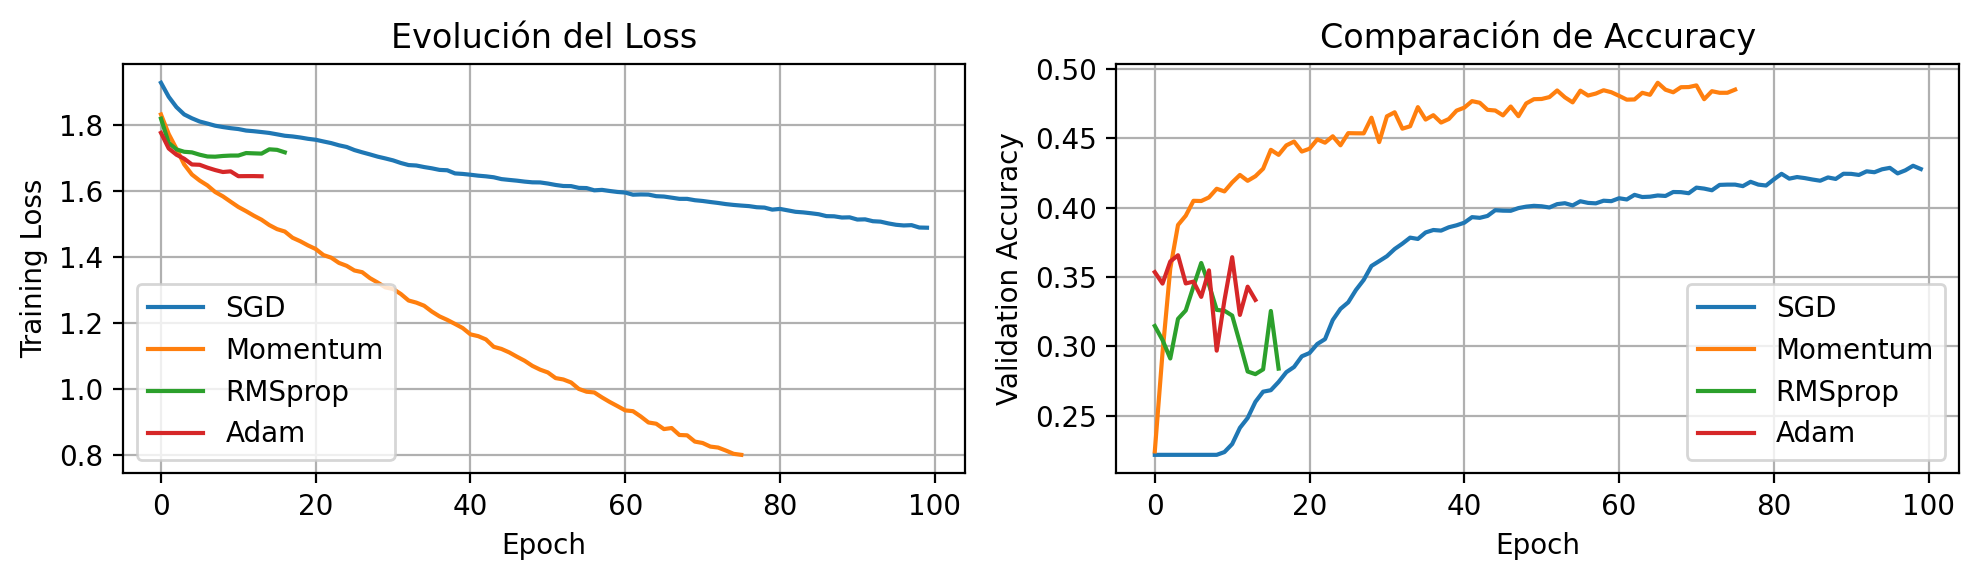

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))

# Curvas de pérdida (loss)
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="SGD")
ax.plot(hist_momentum['loss'], label="Momentum")
ax.plot(hist_rms['loss'], label="RMSprop")
ax.plot(hist_adam['loss'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title("Evolución del Loss")

# Curvas de accuracy en validación
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="SGD")
ax.plot(hist_momentum['val_acc'], label="Momentum")
ax.plot(hist_rms['val_acc'], label="RMSprop")
ax.plot(hist_adam['val_acc'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_title("Comparación de Accuracy")

plt.tight_layout()
plt.show()


adam

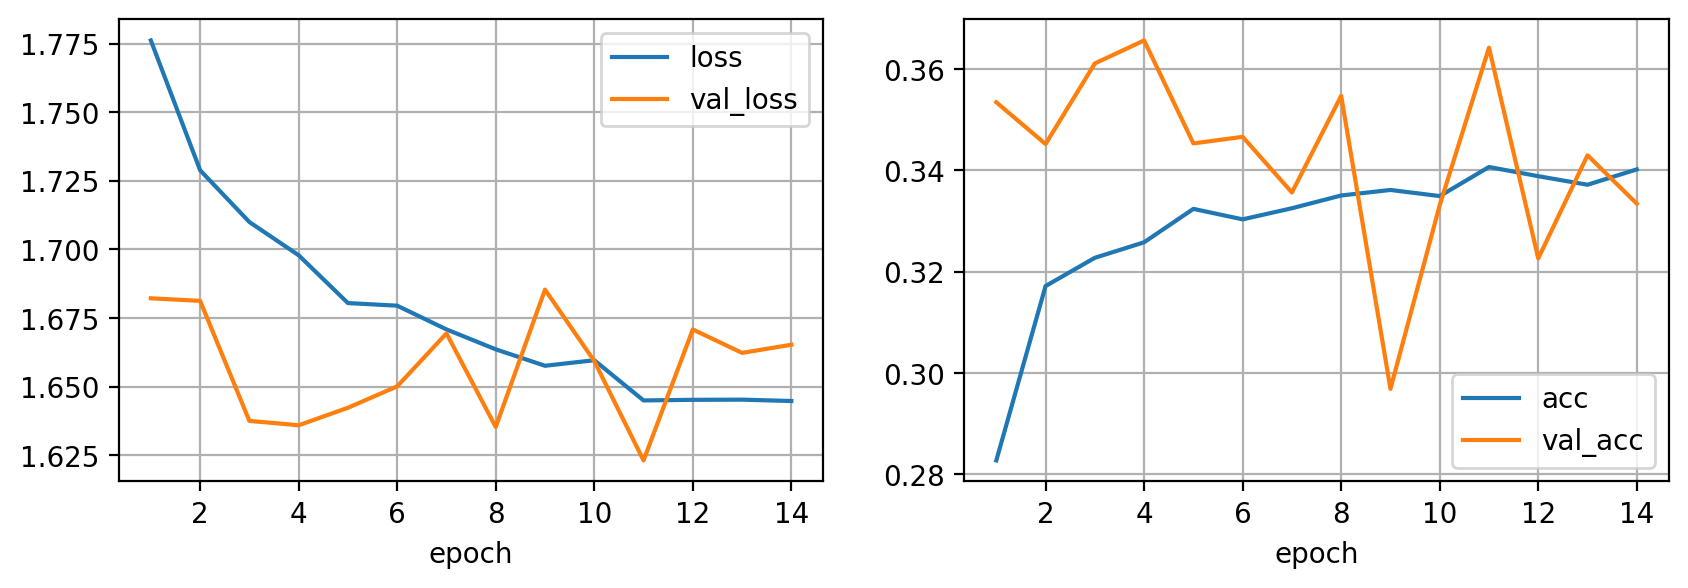

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_adam).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_adam).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

momentum

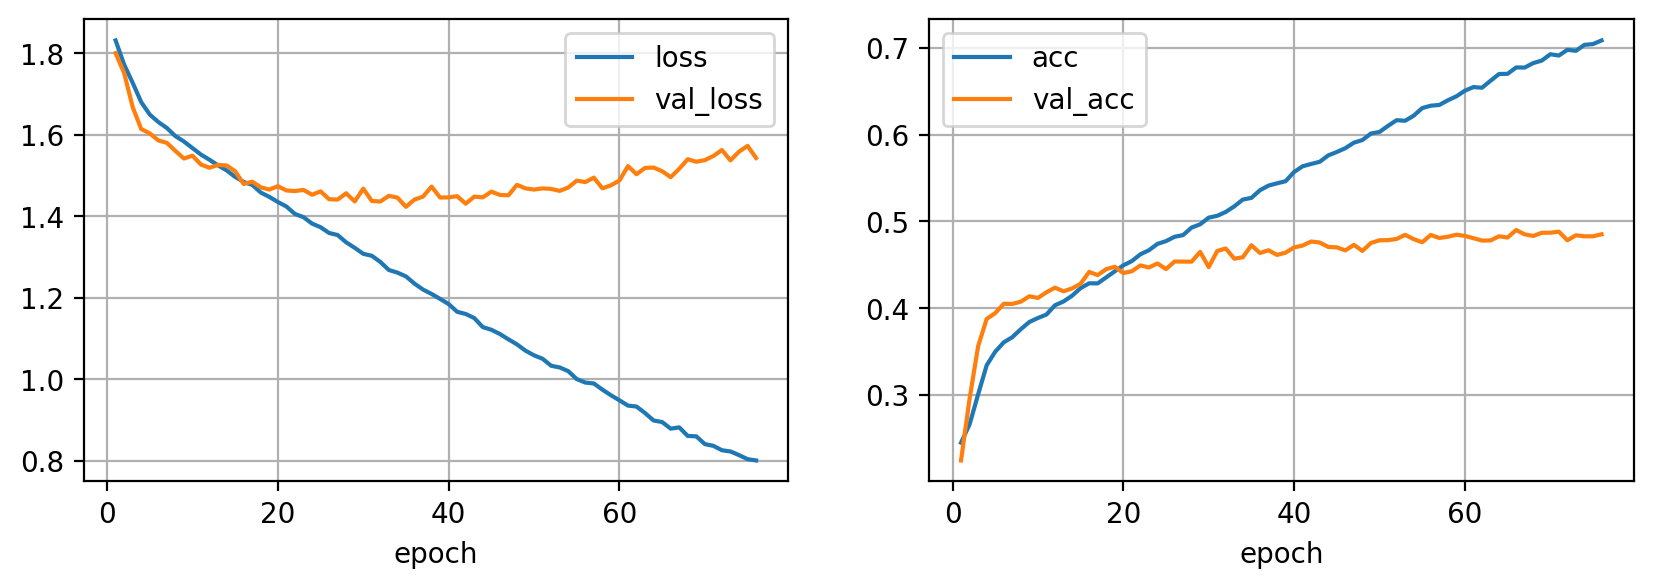

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

rms

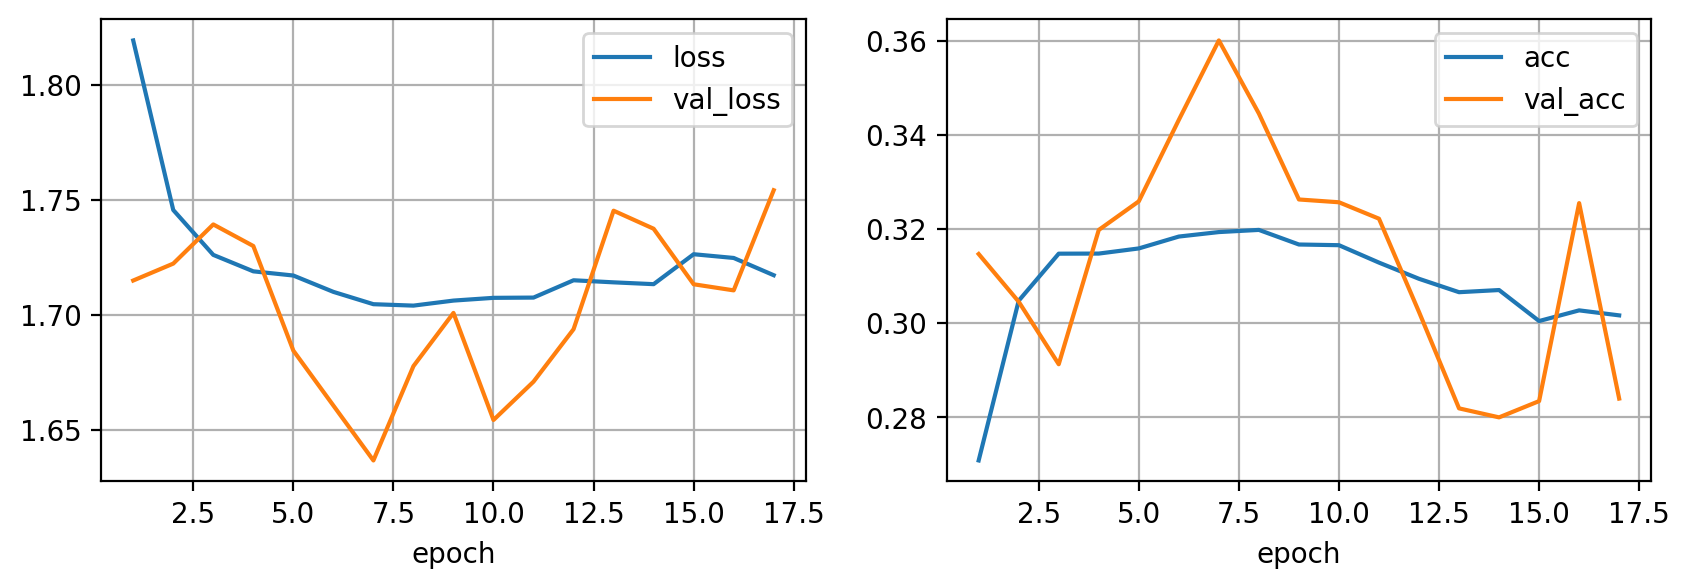

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_rms).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_rms).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

sgd

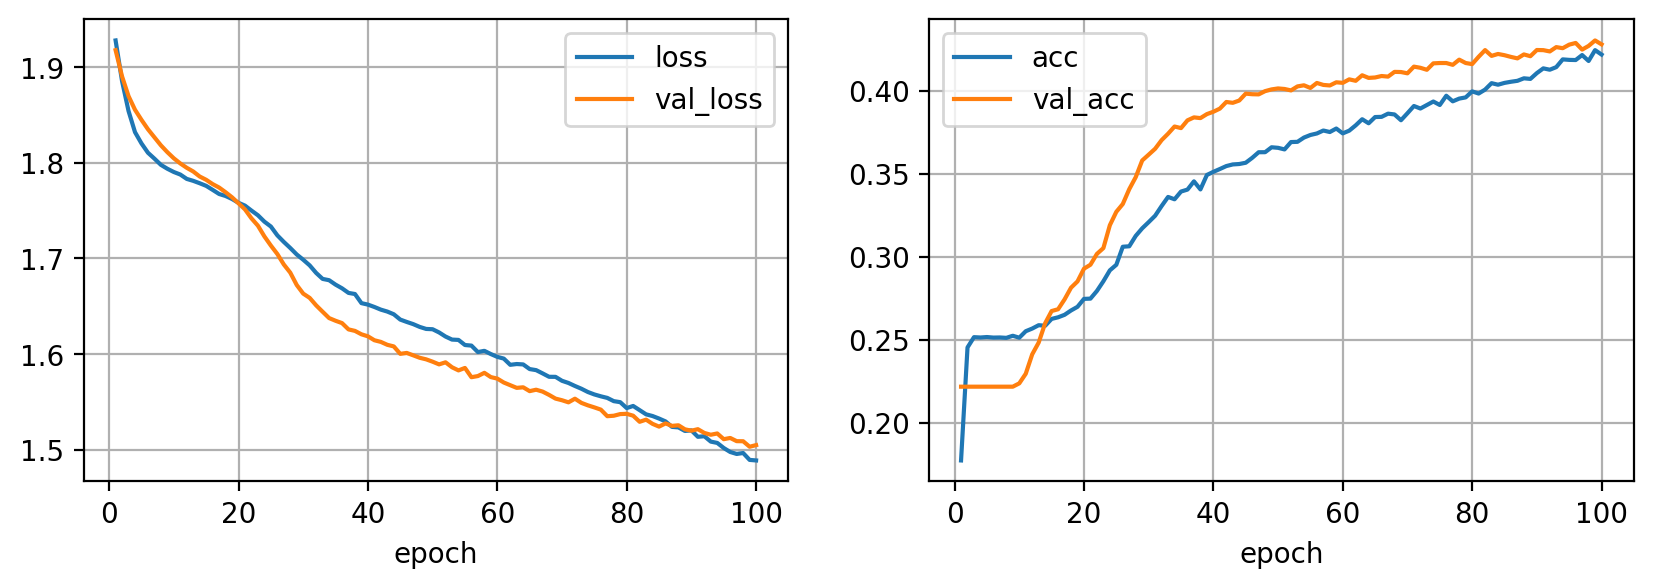

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()